In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

import pandas_datareader.data as web

In [2]:
# Подготовка датасета для обучения в формате inputs, outputs
def make_datasets(input_data, n_inputs=2, n_outputs=1, gap=0):
	L = len(input_data)
	y = np.full((L-n_inputs-n_outputs-gap, n_outputs), 0.0)
	X = np.full((L-n_inputs-n_outputs-gap, n_inputs), 0.0)

	for i in range(n_inputs):
		X[:,i] = input_data[i:L-n_inputs-n_outputs-gap+i]

	for i in range(n_outputs):
		y[:,i] = input_data[n_inputs+gap+i:L-n_outputs+i]

	return X, y

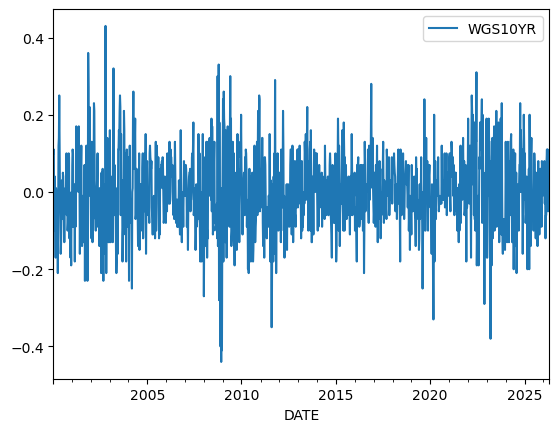

In [3]:
rate = web.DataReader(name='WGS10YR', data_source='fred', start='2000-01-01').diff().dropna()
rate.plot()
plt.show()

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [5]:
# Переведем ряда массив Numpy
series = rate.squeeze().to_numpy()

In [6]:
# задаём ширину окна и горизонт прогнозирования
n_lags, fh= 20, 10

X, y = make_datasets(series, n_inputs=n_lags, n_outputs=fh)

In [7]:
X_tensor = torch.Tensor(X).to(device)
y_tensor = torch.Tensor(y).to(device)

train_dataset = TensorDataset(X_tensor, y_tensor)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [8]:
def train(dataloader, model, loss_fn, optimizer, print_loss=True):
    size = len(dataloader.dataset)

    model.train()                                 # переводим молель в режим обучения
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()                     # Очищаем старые градиенты
        # Compute prediction error
        y_pred = model(X)                         # строми прооноз на батче
        loss = loss_fn(y_pred, y)                 # вычисляем ошибку проноза/значение функции потерь

        # Backpropagation
        loss.backward()                           # Вычисляем градиенты
        optimizer.step()                          # Обновляем веса по градиентам

        if print_loss:
            if batch % 10 == 0:
                loss, current = loss.item(), (batch + 1) * len(X)
                print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


In [9]:
class ExtractTensor(nn.Module):
    def forward(self, x):
        # Если x - кортеж, берем первый элемент
        return x[0] if isinstance(x, tuple) else x

In [10]:
# RNN с одним скрытым слоем
hidden_state = 30

model_rnn = nn.Sequential(
    nn.RNN(n_lags, hidden_state, num_layers=1, nonlinearity='tanh', bidirectional=False),
	# nn.GRU(n_lags, hidden_state, num_layers=1, bidirectional=False),
	# nn.LSTM(n_lags, hidden_state, num_layers=1, bidirectional=False)
	ExtractTensor(),
    nn.Linear(hidden_state, fh)
).to(device)

In [11]:
# GRU с одним скрытым слоем
hidden_state = 30

model_gru = nn.Sequential(
    # nn.RNN(n_lags, hidden_state, num_layers=1, nonlinearity='tanh', bidirectional=False),
	nn.GRU(n_lags, hidden_state, num_layers=1, bidirectional=False),
	# nn.LSTM(n_lags, hidden_state, num_layers=1, bidirectional=False)
	ExtractTensor(),
    nn.Linear(hidden_state, fh)
).to(device)

In [12]:
# LSTM с одним скрытым слоем
hidden_state = 30

model_lstm = nn.Sequential(
    # nn.RNN(n_lags, hidden_state, num_layers=1, nonlinearity='tanh', bidirectional=False),
	# nn.GRU(n_lags, hidden_state, num_layers=1, bidirectional=False),
	nn.LSTM(n_lags, hidden_state, num_layers=1, bidirectional=False),
	ExtractTensor(),
    nn.Linear(hidden_state, fh)
).to(device)

In [13]:
# Обучение
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model_rnn.parameters(), lr=1e-3)
epochs = 10

for epoch in range(epochs):
	print(f"Epoch {epoch+1}\n-------------------------------")
	train(train_dataloader, model_rnn, loss_fn, optimizer)

print("Done!")

Epoch 1
-------------------------------
loss: 0.043483  [   64/ 1343]
loss: 0.019384  [  704/ 1343]
loss: 0.012425  [ 1323/ 1343]
Epoch 2
-------------------------------
loss: 0.011428  [   64/ 1343]
loss: 0.010194  [  704/ 1343]
loss: 0.010836  [ 1323/ 1343]
Epoch 3
-------------------------------
loss: 0.011628  [   64/ 1343]
loss: 0.009348  [  704/ 1343]
loss: 0.010187  [ 1323/ 1343]
Epoch 4
-------------------------------
loss: 0.009439  [   64/ 1343]
loss: 0.011363  [  704/ 1343]
loss: 0.009562  [ 1323/ 1343]
Epoch 5
-------------------------------
loss: 0.009947  [   64/ 1343]
loss: 0.009001  [  704/ 1343]
loss: 0.009146  [ 1323/ 1343]
Epoch 6
-------------------------------
loss: 0.008665  [   64/ 1343]
loss: 0.009348  [  704/ 1343]
loss: 0.009923  [ 1323/ 1343]
Epoch 7
-------------------------------
loss: 0.009823  [   64/ 1343]
loss: 0.008819  [  704/ 1343]
loss: 0.012391  [ 1323/ 1343]
Epoch 8
-------------------------------
loss: 0.009188  [   64/ 1343]
loss: 0.010323  [  7

In [14]:
# Обучение
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model_gru.parameters(), lr=1e-3)
epochs = 10

for epoch in range(epochs):
	print(f"Epoch {epoch+1}\n-------------------------------")
	train(train_dataloader, model_gru, loss_fn, optimizer)

print("Done!")

Epoch 1
-------------------------------
loss: 0.012984  [   64/ 1343]
loss: 0.011165  [  704/ 1343]
loss: 0.011118  [ 1323/ 1343]
Epoch 2
-------------------------------
loss: 0.010363  [   64/ 1343]
loss: 0.010796  [  704/ 1343]
loss: 0.009166  [ 1323/ 1343]
Epoch 3
-------------------------------
loss: 0.010269  [   64/ 1343]
loss: 0.009974  [  704/ 1343]
loss: 0.010399  [ 1323/ 1343]
Epoch 4
-------------------------------
loss: 0.009654  [   64/ 1343]
loss: 0.010514  [  704/ 1343]
loss: 0.009159  [ 1323/ 1343]
Epoch 5
-------------------------------
loss: 0.010270  [   64/ 1343]
loss: 0.009640  [  704/ 1343]
loss: 0.010328  [ 1323/ 1343]
Epoch 6
-------------------------------
loss: 0.010120  [   64/ 1343]
loss: 0.009281  [  704/ 1343]
loss: 0.010141  [ 1323/ 1343]
Epoch 7
-------------------------------
loss: 0.011881  [   64/ 1343]
loss: 0.009992  [  704/ 1343]
loss: 0.010378  [ 1323/ 1343]
Epoch 8
-------------------------------
loss: 0.009928  [   64/ 1343]
loss: 0.010119  [  7

In [15]:
# Обучение
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model_lstm.parameters(), lr=1e-3)
epochs = 10

for epoch in range(epochs):
	print(f"Epoch {epoch+1}\n-------------------------------")
	train(train_dataloader, model_lstm, loss_fn, optimizer)

print("Done!")

Epoch 1
-------------------------------
loss: 0.027354  [   64/ 1343]
loss: 0.018010  [  704/ 1343]
loss: 0.012876  [ 1323/ 1343]
Epoch 2
-------------------------------
loss: 0.012110  [   64/ 1343]
loss: 0.010967  [  704/ 1343]
loss: 0.011606  [ 1323/ 1343]
Epoch 3
-------------------------------
loss: 0.010461  [   64/ 1343]
loss: 0.011197  [  704/ 1343]
loss: 0.009885  [ 1323/ 1343]
Epoch 4
-------------------------------
loss: 0.008694  [   64/ 1343]
loss: 0.011771  [  704/ 1343]
loss: 0.011890  [ 1323/ 1343]
Epoch 5
-------------------------------
loss: 0.009600  [   64/ 1343]
loss: 0.009139  [  704/ 1343]
loss: 0.012456  [ 1323/ 1343]
Epoch 6
-------------------------------
loss: 0.009182  [   64/ 1343]
loss: 0.010845  [  704/ 1343]
loss: 0.010320  [ 1323/ 1343]
Epoch 7
-------------------------------
loss: 0.009208  [   64/ 1343]
loss: 0.009164  [  704/ 1343]
loss: 0.008305  [ 1323/ 1343]
Epoch 8
-------------------------------
loss: 0.010810  [   64/ 1343]
loss: 0.009880  [  7

In [16]:
inputs = torch.Tensor(series[-n_lags:]).unsqueeze(0) # переведём в тензор (1, n_lags)

model_rnn.eval()
with torch.no_grad():  # Отключаем вычисление градиентов
	outputs_rnn = model_rnn(inputs) # получаем тензор размера (1, fh)
    
model_gru.eval()
with torch.no_grad():  # Отключаем вычисление градиентов
	outputs_gru = model_gru(inputs) # получаем тензор размера (1, fh)
    
model_lstm.eval()
with torch.no_grad():  # Отключаем вычисление градиентов
	outputs_lstm = model_lstm(inputs) # получаем тензор размера (1, fh)

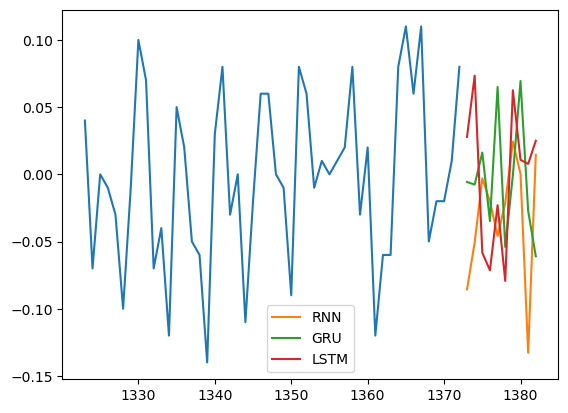

In [18]:
last_obs = 50

y_pred_rnn = outputs_rnn.squeeze().numpy()
y_pred_gru = outputs_gru.squeeze().numpy()
y_pred_lstm = outputs_lstm.squeeze().numpy()

plt.plot(np.arange(len(series)-last_obs, len(series)), series[-last_obs:])
plt.plot(np.arange(len(series), len(series)+fh), y_pred_rnn, label='RNN')
plt.plot(np.arange(len(series), len(series)+fh), y_pred_gru, label='GRU')
plt.plot(np.arange(len(series), len(series)+fh), y_pred_lstm, label='LSTM')
plt.legend()
plt.show()